In [1]:
# Imports
import pandas as pd
import geopandas as gpd
import h5py
import matplotlib.pyplot as plt
import os
import re

In [2]:
# Paths and output directory
climate_file_path = "../../Calabria_dataset/InputReteGood/Climatic/2017/20170701.h5"
save_dir = "plots/climate_plots"
os.makedirs(save_dir, exist_ok=True)

In [3]:
# Load cell-zone mapping and warning areas
df_cell_zones = pd.read_parquet("../1_data/processed/cell_zones.parquet")
gdf_zones = gpd.read_file("../1_data/raw/WarningAreas/WarningAreas.shp")

In [4]:
# Inspect H5 file structure
with h5py.File(climate_file_path, "r") as h5_file:
    print("Top-level keys:", list(h5_file.keys()))
    for key in h5_file.keys():
        print(f"'{key}' contains:", list(h5_file[key].keys()))

Top-level keys: ['attributes', 'values']
'attributes' contains: ['_i_table', 'table']
'values' contains: ['_i_table', 'table']


In [5]:
# Extract grid attributes
with h5py.File(climate_file_path, "r") as h5_file:
    attributes_table = h5_file["attributes/table"][:]

attribute_names = [attr[0].decode() for attr in attributes_table]
attribute_values = [attr[1][0] for attr in attributes_table]
attributes_dict = dict(zip(attribute_names, attribute_values))

ncols = int(attributes_dict["ncols"])
nrows = int(attributes_dict["nrows"])

In [6]:
# Load climate variable names and values
with h5py.File(climate_file_path, "r") as h5_file:
    values_table = h5_file["values/table"]
    climate_names_raw = values_table.attrs["values_block_0_kind"].decode()
    climate_names = re.findall(r'V([A-Za-z0-9_]+)', climate_names_raw)
    table_data = values_table[:]

index_values = table_data["index"]
climate_values = table_data["values_block_0"]

In [7]:
# Convert index to row and column coordinates
row_coords = index_values // ncols
col_coords = index_values % ncols

In [8]:
# Build climate DataFrame with spatial coordinates
df_climate = pd.DataFrame({
    "Row": row_coords,
    "Column": col_coords,
    "Precipitation": climate_values[:, 0],
    "Humidity": climate_values[:, 1],
    "Temperature": climate_values[:, 2],
    "Wind": climate_values[:, 3],
    "X_Coord": attributes_dict["xllcorner"] + (col_coords * attributes_dict["cellsize"]),
    "Y_Coord": attributes_dict["yllcorner"] + ((nrows - 1 - row_coords) * attributes_dict["cellsize"])
})

df_climate.head()

,Row,Column,Precipitation,Humidity,Temperature,Wind,X_Coord,Y_Coord
0,0,0,NaN,NaN,NaN,NaN,549915.375,4448479.25
1,0,1,NaN,NaN,NaN,NaN,550015.375,4448479.25
2,0,2,NaN,NaN,NaN,NaN,550115.375,4448479.25
3,0,3,NaN,NaN,NaN,NaN,550215.375,4448479.25
4,0,4,NaN,NaN,NaN,NaN,550315.375,4448479.25


In [9]:
# Adjust Y coordinate precision
df_climate["Y_Coord"] = df_climate["Y_Coord"].round(-0).astype(float).round(1)

In [10]:
# Merge climate data with zone mapping
df_climate = df_cell_zones[["X_Coord", "Y_Coord", "Zone_ID"]].merge(
    df_climate,
    on=["X_Coord", "Y_Coord"],
    how="left"
)

In [11]:
# Convert to GeoDataFrame
gdf_climate_zones = gpd.GeoDataFrame(
    df_climate,
    geometry=gpd.points_from_xy(df_climate["X_Coord"], df_climate["Y_Coord"]),
    crs="EPSG:32633"
)

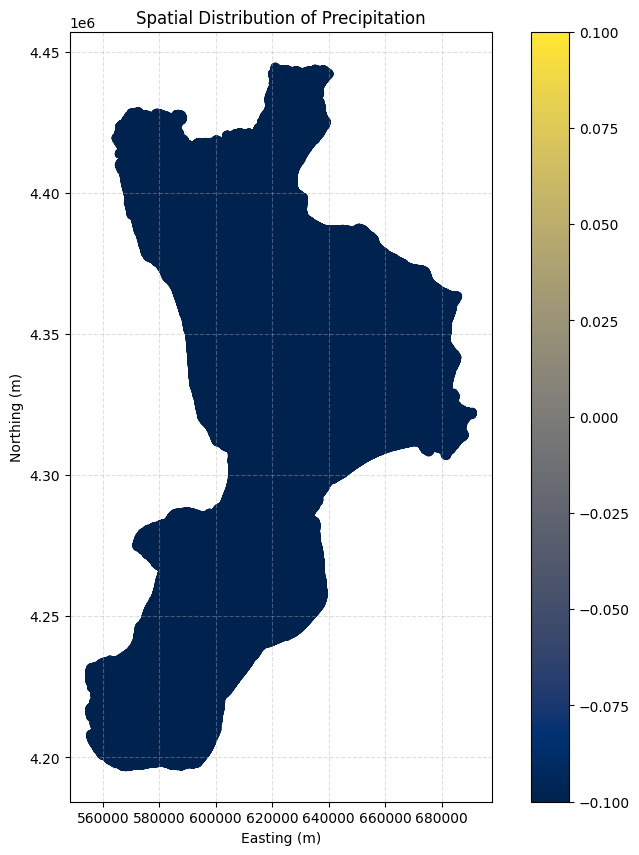

In [13]:
# Plot precipitation spatial distribution
fig, ax = plt.subplots(figsize=(10, 10))
gdf_zones.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5)
gdf_climate_zones.plot(column="Precipitation", cmap="cividis", legend=True, ax=ax, markersize=30)
plt.title("Spatial Distribution of Precipitation")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.savefig(os.path.join(save_dir, "precipitation_map.png"), dpi=300, bbox_inches='tight')

In [ ]:
# Plot humidity spatial distribution
fig, ax = plt.subplots(figsize=(10, 10))
gdf_zones.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5)
gdf_climate_zones.plot(column="Humidity", cmap="viridis", legend=True, ax=ax, markersize=30)
plt.title("Spatial Distribution of Humidity")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.savefig(os.path.join(save_dir, "humidity_map.png"), dpi=300, bbox_inches='tight')

In [ ]:
# Plot temperature spatial distribution
fig, ax = plt.subplots(figsize=(10, 10))
gdf_zones.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5)
gdf_climate_zones.plot(column="Temperature", cmap="plasma", legend=True, ax=ax, markersize=30)
plt.title("Spatial Distribution of Temperature")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.savefig(os.path.join(save_dir, "temperature_map.png"), dpi=300, bbox_inches='tight')

In [ ]:
# Plot wind speed spatial distribution
fig, ax = plt.subplots(figsize=(10, 10))
gdf_zones.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5)
gdf_climate_zones.plot(column="Wind", cmap="PuOr", legend=True, ax=ax, markersize=30)
plt.title("Spatial Distribution of Wind Speed")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.savefig(os.path.join(save_dir, "wind_map.png"), dpi=300, bbox_inches='tight')